# Project 2 - Statistical Plots & Distribution Analysis
Internship Task - Syntecxhub (Data Science)

Dataset used: seaborn built-in `tips` dataset (total_bill, tip, day, time, sex etc.)

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os

# folder to save all the plots
os.makedirs('outputs', exist_ok=True)

sns.set(style='darkgrid')

var3 = sns.load_dataset('tips')
var3.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
var3.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## 1. Histogram + KDE
checking the shape of `total_bill` - is it normal, skewed, etc.

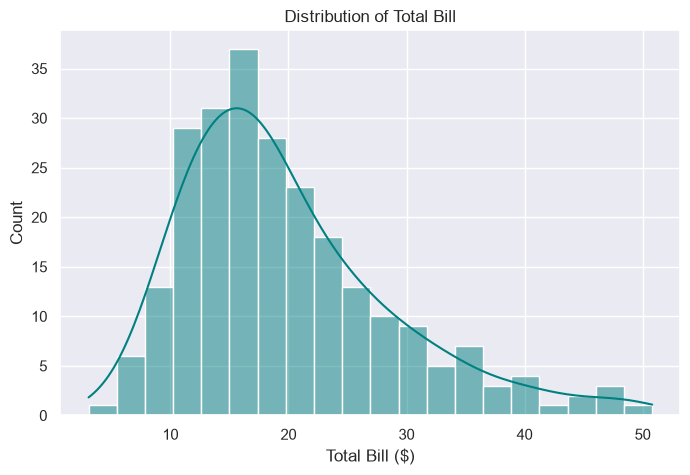

In [3]:
plt.figure(figsize=(8,5))
sns.histplot(var3['total_bill'], kde=True, bins=20, color='teal')
plt.title('Distribution of Total Bill')
plt.xlabel('Total Bill ($)')
plt.ylabel('Count')
plt.savefig('outputs/histogram_total_bill.png', dpi=150, bbox_inches='tight')
plt.show()

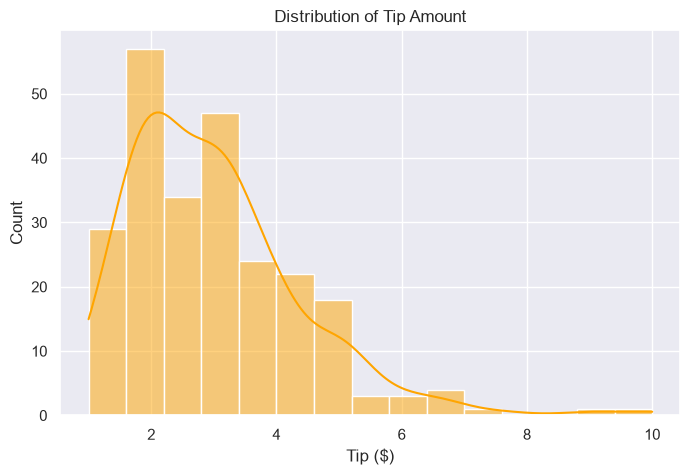

In [4]:
# same thing but for tip amount, just to compare
plt.figure(figsize=(8,5))
sns.histplot(var3['tip'], kde=True, bins=15, color='orange')
plt.title('Distribution of Tip Amount')
plt.xlabel('Tip ($)')
plt.savefig('outputs/histogram_tip.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Boxplot
used to see the spread and spot outliers in each group

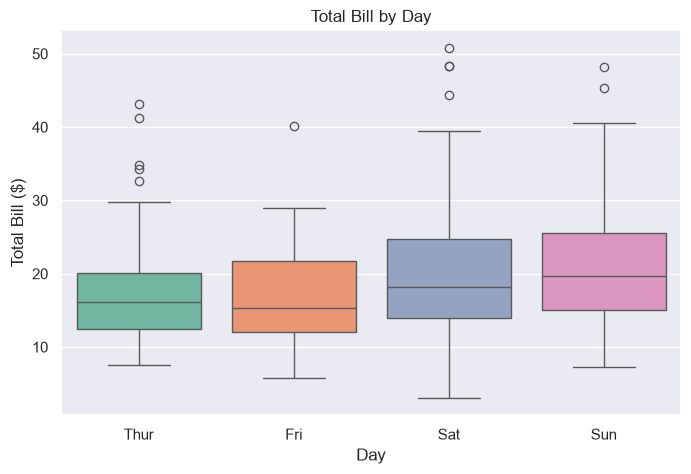

In [5]:
plt.figure(figsize=(8,5))
sns.boxplot(x='day', y='total_bill', data=var3, hue='day',
            order=['Thur','Fri','Sat','Sun'], palette='Set2', legend=False)
plt.title('Total Bill by Day')
plt.xlabel('Day')
plt.ylabel('Total Bill ($)')
plt.savefig('outputs/boxplot_bill_by_day.png', dpi=150, bbox_inches='tight')
plt.show()

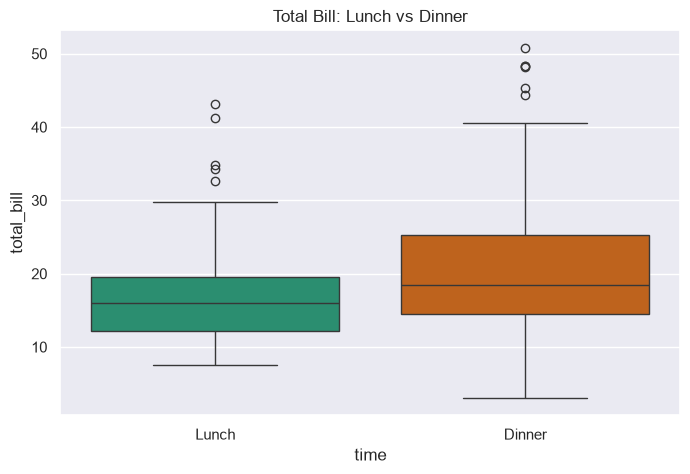

In [6]:
# same boxplot but split lunch vs dinner instead of day
plt.figure(figsize=(8,5))
sns.boxplot(x='time', y='total_bill', data=var3, hue='time',
            order=['Lunch','Dinner'], palette='Dark2', legend=False)
plt.title('Total Bill: Lunch vs Dinner')
plt.savefig('outputs/boxplot_bill_by_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Comparing distributions across groups (violin plot)
violin plot shows the same thing as boxplot but also shows the actual shape/density, so easier to compare

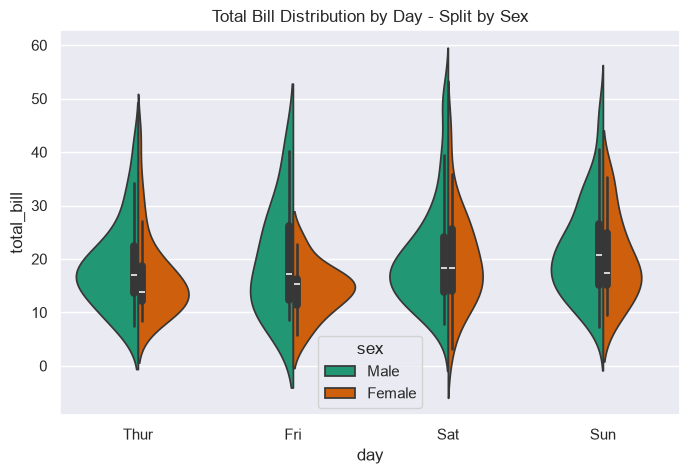

In [7]:
plt.figure(figsize=(8,5))
sns.violinplot(x='day', y='total_bill', data=var3, hue='sex',
               palette='Dark2', split=True, legend=True, saturation=0.9)
plt.title('Total Bill Distribution by Day - Split by Sex')
plt.savefig('outputs/violin_bill_by_day_sex.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Outlier check (quick manual method using IQR)
instead of just eyeballing the boxplot, calculating it properly

In [8]:
Q1 = var3['total_bill'].quantile(0.25)
Q3 = var3['total_bill'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR

outliers = var3[(var3['total_bill'] < lower_limit) | (var3['total_bill'] > upper_limit)]
print('lower limit:', lower_limit)
print('upper limit:', upper_limit)
print('number of outliers:', len(outliers))
outliers[['total_bill','day','time','sex']]

lower limit: -2.8224999999999945
upper limit: 40.29749999999999
number of outliers: 9


,total_bill,day,time,sex
59,48.27,Sat,Dinner,Male
102,44.30,Sat,Dinner,Female
142,41.19,Thur,Lunch,Male
156,48.17,Sun,Dinner,Male
170,50.81,Sat,Dinner,Male
182,45.35,Sun,Dinner,Male
184,40.55,Sun,Dinner,Male
197,43.11,Thur,Lunch,Female
212,48.33,Sat,Dinner,Male


## 5. Skewness check

In [9]:
print('Skewness of total_bill:', var3['total_bill'].skew())
print('Skewness of tip:', var3['tip'].skew())
# positive value = right skewed (tail on the right side)

Skewness of total_bill: 1.1332130376158205
Skewness of tip: 1.4654510370979401


## Interpretation

The `total_bill` distribution is right-skewed (skew value came out positive, around 1.1), meaning most bills are on the lower/mid side (roughly $10-$20) but a few big bills pull the tail toward $40-50. Same pattern shows up in `tip`, just smaller scale.

From the boxplot, **Saturday** has the highest median total_bill and also the most outliers above the upper limit, so weekend spending is not just higher on average but more unpredictable too. Lunch vs Dinner boxplot shows Dinner bills are higher and more spread out than Lunch, which makes sense since dinner usually means bigger orders.

The IQR method flagged a small number of outliers on the higher end of total_bill (mostly the bigger dinner tables), no low-end outliers.

Split violin plot (day vs sex) shows male total_bill distribution is a little wider/shifted higher than female on most days, but the overall shape (right-skewed) stays the same for both - so gender doesn't change the *pattern*, just shifts it a bit.